## 1. Confirm the GPU

In [1]:
!nvidia-smi
import torch
print('torch', torch.__version__, '| cuda available:', torch.cuda.is_available())
assert torch.cuda.is_available(), 'No GPU. Notebook settings (right panel) -> Accelerator -> GPU T4 x2'

Sun Sep 20 06:29:17 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.159.04             Driver Version: 580.159.04     CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   43C    P8             10W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

## 2. Locate the attached dataset

Auto-detects the mounted dataset by looking for `Dataset/Img` under `/kaggle/input`, so you don't need to hardcode your dataset's slug.

In [2]:
import os

def find_input_root(target=os.path.join('Dataset', 'Img')):
    for root, dirs, files in os.walk('/kaggle/input/datasets/faiyazabrar/mulad-memedecoder'):
        if root.endswith(target):
            return os.path.dirname(os.path.dirname(root))  # strip 'Img', then 'Dataset'
    return None

INPUT_ROOT = find_input_root()
assert INPUT_ROOT, (
    'No Dataset/Img found anywhere under /kaggle/input. '
    'Run print(os.listdir("/kaggle/input/datasets")) to inspect the real layout.'
)
print('Dataset mount:', INPUT_ROOT)
print('memes    :', len(os.listdir(f'{INPUT_ROOT}/Dataset/Img')))
print(sorted(os.listdir(INPUT_ROOT)))

Dataset mount: /kaggle/input/datasets/faiyazabrar/mulad-memedecoder
memes    : 4848
['Dataset', 'README.md', 'Scripts', 'requirements.txt']


## 3. Install dependencies

Kaggle notebooks already ship a CUDA build of torch, so only the extras are installed — notably CLIP from source, exactly as the original `requirements.txt` specifies.

In [3]:
!pip install -q transformers sentencepiece imbalanced-learn madgrad ftfy regex
!pip install -q git+https://github.com/openai/CLIP.git

import clip, transformers
print('transformers', transformers.__version__)
print('clip OK')

  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 1.1 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
transformers 5.0.0
clip OK


## 4. Set up a writable working copy

`/kaggle/input` is read-only, but `main.py` needs to create `Saved_Models/`, `Outputs/` and a `.cache/` next to `Scripts/`. So `Scripts/` (a few hundred KB) is copied to `/kaggle/working`; `Dataset/` (365 MB of images) stays on the read-only input mount and is referenced by an absolute path — no need to duplicate it.

In [4]:
import shutil

ROOT = '/kaggle/working/Replication'
os.makedirs(ROOT, exist_ok=True)

if os.path.isdir(f'{ROOT}/Scripts'):
    shutil.rmtree(f'{ROOT}/Scripts')
shutil.copytree(f'{INPUT_ROOT}/Scripts', f'{ROOT}/Scripts')
shutil.copy(f'{INPUT_ROOT}/requirements.txt', ROOT)

DATASET_PATH = f'{INPUT_ROOT}/Dataset'  # absolute path -> main.py reads straight from the input mount
print('Working scripts at:', f'{ROOT}/Scripts')
print('Reading dataset from (read-only):', DATASET_PATH)

Working scripts at: /kaggle/working/Replication/Scripts
Reading dataset from (read-only): /kaggle/input/datasets/faiyazabrar/mulad-memedecoder/Dataset


## 5. Splits summary (cf. paper Table 1)

In [5]:
import pandas as pd
for name in ['training_set', 'validation_set', 'testing_set']:
    df = pd.read_csv(f'{DATASET_PATH}/{name}.csv')
    print(f'{name:<16} {len(df):>5} rows   ', dict(df["Label"].value_counts()))

training_set      3393 rows    {'non-aggressive': np.int64(846), 'gendered aggression': np.int64(672), 'others': np.int64(660), 'religious aggression': np.int64(618), 'political aggression': np.int64(597)}
validation_set     727 rows    {'non-aggressive': np.int64(181), 'gendered aggression': np.int64(144), 'others': np.int64(141), 'religious aggression': np.int64(133), 'political aggression': np.int64(128)}
testing_set        728 rows    {'non-aggressive': np.int64(182), 'gendered aggression': np.int64(144), 'others': np.int64(142), 'religious aggression': np.int64(132), 'political aggression': np.int64(128)}


## 6. Smoke test

Runs the full pipeline on a handful of memes for one epoch. This is **not a result** — it only proves the data, the model and the metrics all wire up before committing to a long run.

In [6]:
%cd {ROOT}/Scripts
!python main.py --dataset "{DATASET_PATH}" --subset 24 --n_iter 1 --run_name kaggle_smoketest

/kaggle/working/Replication/Scripts
Device: cuda:0
Fetching Dataset... 
-----------------------------
Maximum Text Length:  70
Batch Size:  4
Classes: 5 ['NoAg', 'GAg', 'PAg', 'RAg', 'Oth']
SUBSET MODE: 20 rows per split (smoke test, not a real result)
Training Data: 20
Valid Data: 20
Test Data: 20
config.json: 100%|█████████████████████████████| 491/491 [00:00<00:00, 2.81MB/s]
vocab.txt: 2.24MB [00:00, 50.6MB/s]
Fetched.
Time required for preparing the Data loaders: 2.87s
--------------------------------
Checkpoint file: /kaggle/working/Replication/Saved_Models/maf_model_kaggle_smoketest.pth
100%|████████████████████████████████████████| 338M/338M [00:02<00:00, 125MiB/s]
model.safetensors: 100%|██████████████████████| 660M/660M [00:04<00:00, 163MB/s]
Loading weights: 100%|█| 199/199 [00:00<00:00, 1652.05it/s, Materializing param=
BertModel LOAD REPORT from: sagorsarker/bangla-bert-base
Key                                        | Status     |  | 
--------------------------------------

## 7. The real run

Paper hyperparameters (Appendix A): batch 4, 20 epochs, lr 5e-5, 16 attention heads, max_len 70.

The best-validation-accuracy checkpoint is kept and used for the test evaluation, as in the original. Mind Kaggle's session time limit (~9–12 hrs) — this run is expected to take 1–2 hrs on a T4.

In [7]:
%cd {ROOT}/Scripts
!python main.py --dataset "{DATASET_PATH}" --run_name maf_full --batch_size 16 --n_iter 5 --lrate 5e-5 --heads 16 --max_len 70

/kaggle/working/Replication/Scripts
Device: cuda:0
Fetching Dataset... 
-----------------------------
Maximum Text Length:  70
Batch Size:  16
Classes: 5 ['NoAg', 'GAg', 'PAg', 'RAg', 'Oth']
Training Data: 3393
Valid Data: 727
Test Data: 728
Fetched.
Time required for preparing the Data loaders: 1.14s
--------------------------------
Checkpoint file: /kaggle/working/Replication/Saved_Models/maf_model_maf_full.pth
Loading weights: 100%|█| 199/199 [00:00<00:00, 1629.30it/s, Materializing param=
BertModel LOAD REPORT from: sagorsarker/bangla-bert-base
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predict

## 8. Ablations and variants (optional)

- `--attn_variant paper` — the attention operand order the **paper text** describes (Q from text, K/V from vision), rather than the order the **released code** implements. See README §5.4.
- `--fix_scheduler` — steps the LR scheduler per batch instead of per epoch, correcting the original's scheduler bug. See README §5.5.

In [8]:
%cd {ROOT}/Scripts
!python main.py --dataset "{DATASET_PATH}" --run_name maf_paper_attn --attn_variant paper --batch_size 16 --n_iter 5 --lrate 5e-5 --heads 16 --max_len 70
!python main.py --dataset "{DATASET_PATH}" --run_name maf_fixed_sched --fix_scheduler --batch_size 16 --n_iter 5 --lrate 5e-5 --heads 16 --max_len 70

/kaggle/working/Replication/Scripts
Device: cuda:0
Fetching Dataset... 
-----------------------------
Maximum Text Length:  70
Batch Size:  16
Classes: 5 ['NoAg', 'GAg', 'PAg', 'RAg', 'Oth']
Training Data: 3393
Valid Data: 727
Test Data: 728
Fetched.
Time required for preparing the Data loaders: 1.14s
--------------------------------
Checkpoint file: /kaggle/working/Replication/Saved_Models/maf_model_maf_paper_attn.pth
Loading weights: 100%|█| 199/199 [00:00<00:00, 1912.53it/s, Materializing param=
BertModel LOAD REPORT from: sagorsarker/bangla-bert-base
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.s

## 9. Results

Compares every run in `Outputs/` against both papers' published rows.

**This is now a like-for-like reproduction.** The corpus is the full five-way MIMOSA that
MAF was published on, and the captions are the dataset authors' own hand-corrected text, so
the published MAF row is a real target rather than a loose reference. That was not true of
the earlier four-class OCR'd corpus, where the gap was dominated by caption noise.

MuLAD runs, if present, are listed separately - see README §7.


In [9]:
import glob, json
import pandas as pd

rows = []
for path in sorted(glob.glob(f'{ROOT}/Outputs/results_*.json')):
    r = json.load(open(path, encoding='utf-8'))
    if r.get('hyperparameters', {}).get('subset'):
        continue                                  # smoke tests are not results
    rows.append({
        'run': r['run_name'],
        'framework': r.get('framework', 'MAF'),
        'Acc': round(r['accuracy'], 3),
        'WF1': round(r['weighted_f1'], 3),
        'MacroF1': round(r['macro_f1'], 3),
        'MMAE': round(r['mmae'], 3),
    })

table = pd.DataFrame(rows).sort_values('WF1', ascending=False)
for fw in table['framework'].unique():
    print(f'--- {fw} ---')
    print(table[table['framework'] == fw].drop(columns='framework').to_string(index=False))
    print()

print('Published reference points')
print('  MAF   (Ahsan et al. 2024, 5-way MIMOSA) : Acc 0.741  WF1 0.742  MMAE 0.645  <- like-for-like')
print('  MuLAD (Hasan et al., BINARY AMemD)      : Acc 0.778  WF1 0.738   (different task and corpus)')


--- MAF ---
            run   Acc   WF1  MacroF1  MMAE
maf_fixed_sched 0.716 0.718    0.727 0.702
 maf_paper_attn 0.710 0.711    0.720 0.724
       maf_full 0.707 0.709    0.719 0.725

Published reference points
  MAF   (Ahsan et al. 2024, 5-way MIMOSA) : Acc 0.741  WF1 0.742  MMAE 0.645  <- like-for-like
  MuLAD (Hasan et al., BINARY AMemD)      : Acc 0.778  WF1 0.738   (different task and corpus)


## 10. Confusion matrix

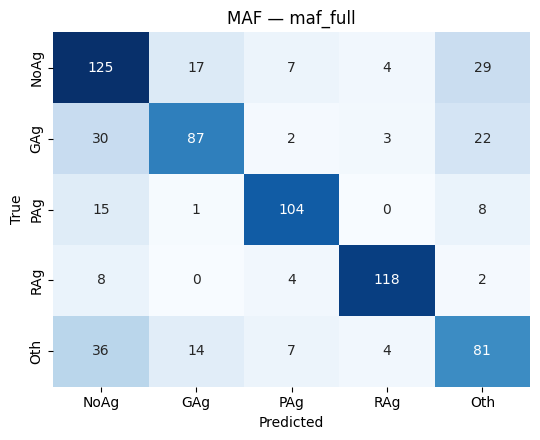

In [10]:
import json
import matplotlib.pyplot as plt
import seaborn as sns

RUN = 'maf_full'
r = json.load(open(f'{ROOT}/Outputs/results_{RUN}.json', encoding='utf-8'))

plt.figure(figsize=(5.5, 4.5))
sns.heatmap(r['confusion_matrix'], annot=True, fmt='d', cmap='Blues',
            xticklabels=r['target_names'], yticklabels=r['target_names'], cbar=False)
plt.xlabel('Predicted'); plt.ylabel('True'); plt.title(f'MAF — {RUN}')
plt.tight_layout(); plt.show()

## 11. Results persist automatically

Everything under `/kaggle/working` (including `{ROOT}/Outputs` and `{ROOT}/Saved_Models`) is kept as the notebook's **Output** when you commit/save the session — download it from the notebook's "Output" tab afterward. No extra copy step needed (unlike Colab, which needs an explicit copy back to Drive).

In [11]:
!ls -lh {ROOT}/Outputs {ROOT}/Saved_Models

/kaggle/working/Replication/Outputs:
total 564K
-rw-r--r-- 1 root root 4.6K Sep 20 06:30 predictions_kaggle_smoketest.csv
-rw-r--r-- 1 root root 178K Sep 20 07:13 predictions_maf_fixed_sched.csv
-rw-r--r-- 1 root root 179K Sep 20 06:44 predictions_maf_full.csv
-rw-r--r-- 1 root root 179K Sep 20 06:59 predictions_maf_paper_attn.csv
-rw-r--r-- 1 root root 1.8K Sep 20 06:30 results_kaggle_smoketest.json
-rw-r--r-- 1 root root 2.1K Sep 20 07:13 results_maf_fixed_sched.json
-rw-r--r-- 1 root root 2.1K Sep 20 06:44 results_maf_full.json
-rw-r--r-- 1 root root 2.1K Sep 20 06:59 results_maf_paper_attn.json

/kaggle/working/Replication/Saved_Models:
total 3.9G
-rw-r--r-- 1 root root 975M Sep 20 06:30 maf_model_kaggle_smoketest.pth
-rw-r--r-- 1 root root 975M Sep 20 07:01 maf_model_maf_fixed_sched.pth
-rw-r--r-- 1 root root 975M Sep 20 06:34 maf_model_maf_full.pth
-rw-r--r-- 1 root root 975M Sep 20 06:47 maf_model_maf_paper_attn.pth
